<a href="https://colab.research.google.com/github/Harsh202020/DMA-Research/blob/main/DMA_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

Uploading Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving airlines_flights_data.csv to airlines_flights_data.csv


In [ ]:
df = pd.read_csv("airlines_flights_data.csv")
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (300153, 12)


,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


Basic cleaning and checks

In [ ]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic statistics:\n", df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB
None

Missing values:
 index               0
airline             0
flight              0
source_city         0
departure_time      0
stops               0

**Exploratory Data Analysis (EDA) + Visualizations**



Market share of airlines

“In this dataset, Vistara has the highest share, followed by IndiGo…”

“However, real-world DGCA data shows IndiGo as the actual market leader.”

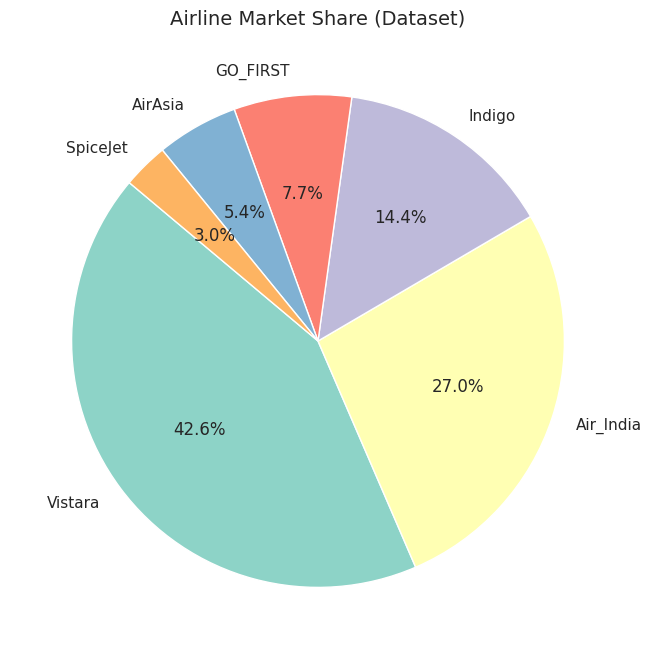

Airline flight counts in dataset:
 airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64


In [ ]:
airline_counts = df["airline"].value_counts()

plt.figure(figsize=(8,8))
plt.pie(airline_counts, labels=airline_counts.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette("Set3"))
plt.title("Airline Market Share (Dataset)", fontsize=14)
plt.show()

print("Airline flight counts in dataset:\n", airline_counts)


distribution of ticket prices

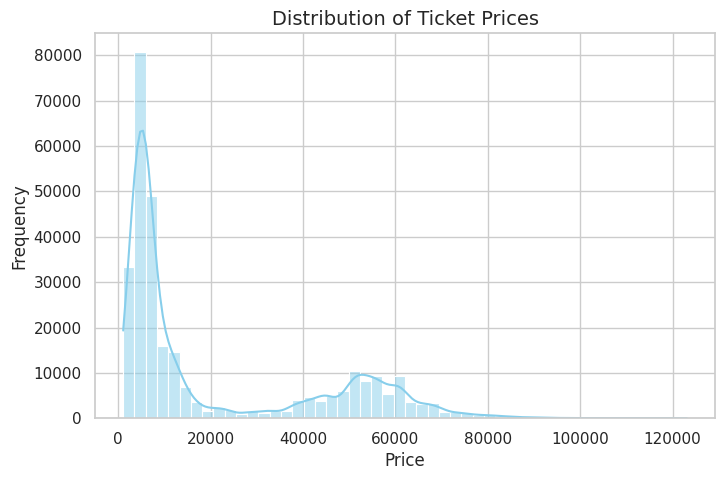

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=50, kde=True, color="skyblue")
plt.title("Distribution of Ticket Prices", fontsize=14)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Airlines vs average prices

/tmp/ipython-input-3270238418.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x="airline", y="price", data=df, estimator=np.mean, ci=None, palette="Set2")
/tmp/ipython-input-3270238418.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="airline", y="price", data=df, estimator=np.mean, ci=None, palette="Set2")


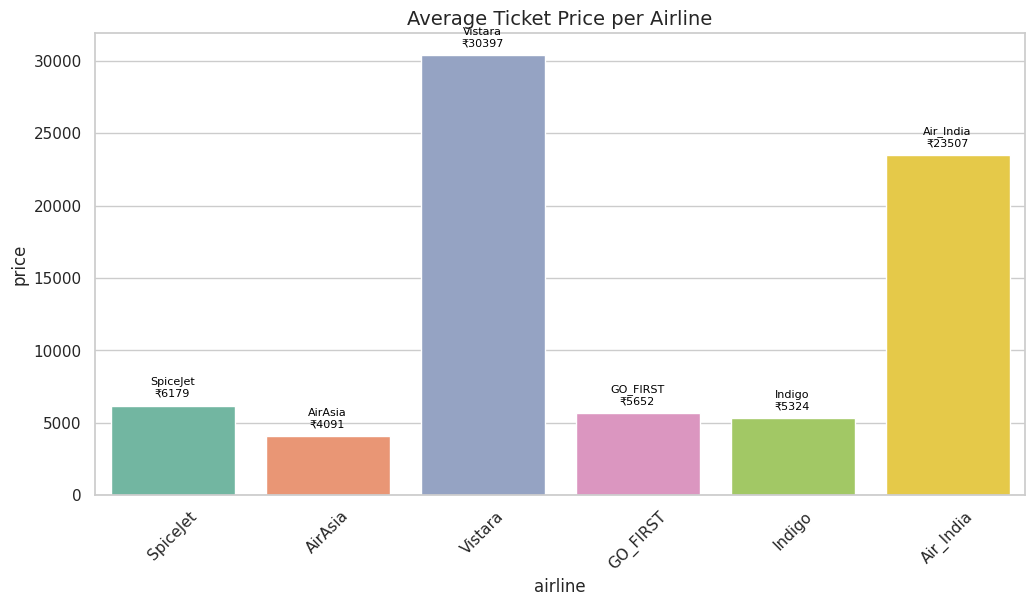

In [ ]:
plt.figure(figsize=(12,6))
ax = sns.barplot(x="airline", y="price", data=df, estimator=np.mean, ci=None, palette="Set2")
plt.title("Average Ticket Price per Airline", fontsize=14)
plt.xticks(rotation=45)

for p, airline in zip(ax.patches, df["airline"].unique()):
    ax.annotate(f"{airline}\n₹{p.get_height():.0f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=8, color="black", xytext=(0, 5),
                textcoords="offset points")
plt.show()


Price Distribution by Airline

* Shows how ticket prices vary within each airline.

* Useful to analyze which airline has high variance (premium vs budget).

/tmp/ipython-input-728317775.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="airline", y="price", data=df, palette="Set2")


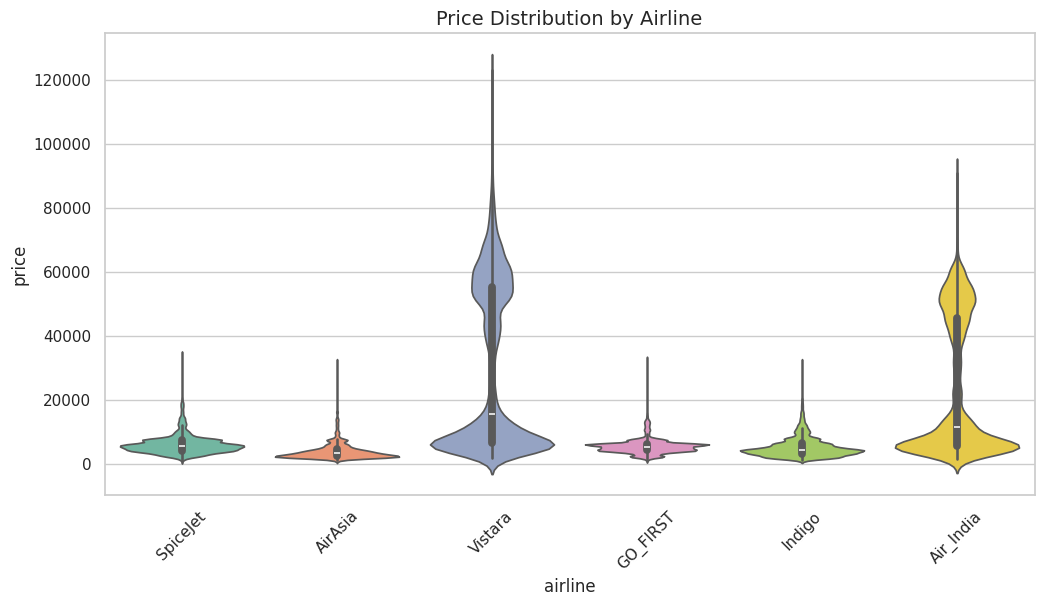

In [ ]:
plt.figure(figsize=(12,6))
sns.violinplot(x="airline", y="price", data=df, palette="Set2")
plt.title("Price Distribution by Airline", fontsize=14)
plt.xticks(rotation=45)
plt.show()


Insight: Budget airlines (IndiGo, SpiceJet) have tight clusters, premium airlines (Vistara, Air India) show wider spread.

Stops vs price

/tmp/ipython-input-782902584.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="stops", y="price", data=df, palette="Set3")


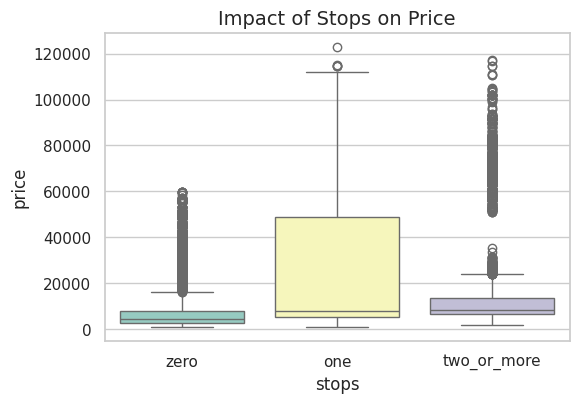

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="stops", y="price", data=df, palette="Set3")
plt.title("Impact of Stops on Price", fontsize=14)
plt.show()

Days left vs price

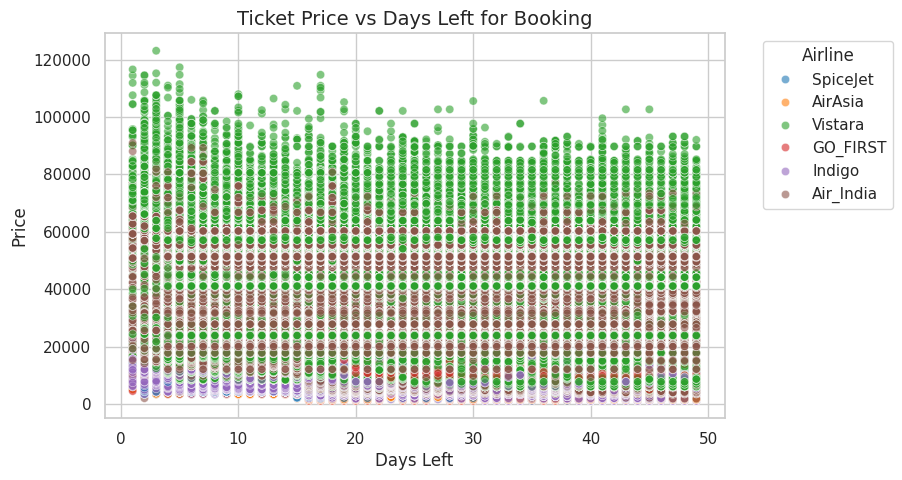

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="days_left", y="price", data=df, hue="airline", alpha=0.6, palette="tab10")
plt.title("Ticket Price vs Days Left for Booking", fontsize=14)
plt.xlabel("Days Left")
plt.ylabel("Price")
plt.legend(title="Airline", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Heatmap - average price by city pairs

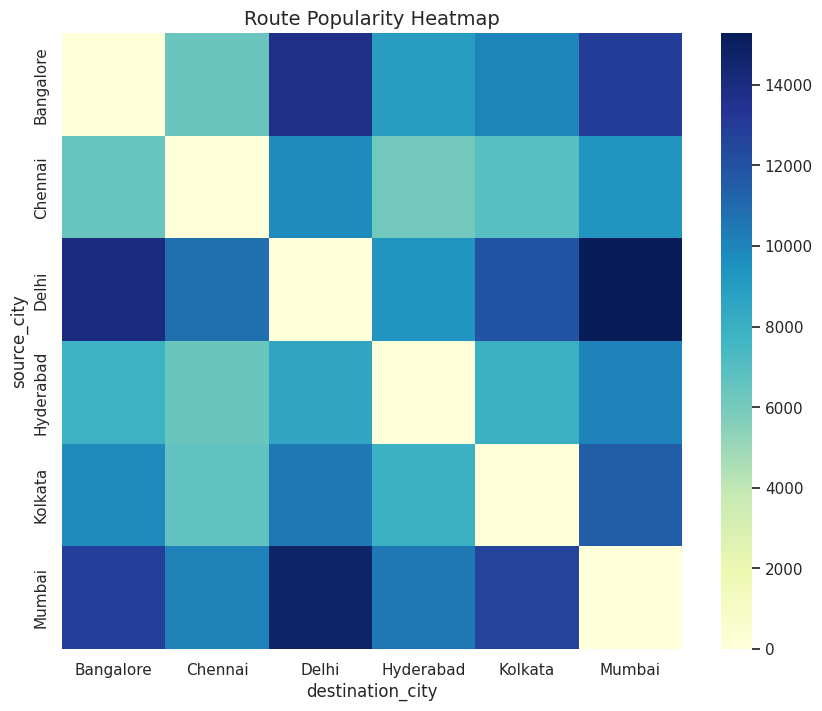

In [ ]:
route_counts = df.groupby(["source_city", "destination_city"]).size().unstack(fill_value=0)
plt.figure(figsize=(10,8))
sns.heatmap(route_counts, cmap="YlGnBu", annot=False)
plt.title("Route Popularity Heatmap", fontsize=14)
plt.show()


ML Models (Regression Example — Predict Price)

In [ ]:
f_sample = df.sample(frac=0.2, random_state=42)
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=50,   # fewer trees
    max_depth=10,      # limit depth
    n_jobs=-1,         # use all CPU cores
    random_state=42
)
model.fit(X_train, y_train)


from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

lr = LinearRegression()
lr.fit(X_train, y_train)

dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=10, random_state=42)

Artificial Neural Network (ANN) for Price Prediction

In [ ]:
# STEP 5: ANN (Deep Learning) for Ticket Price Prediction

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split again (scaled features)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Build ANN model
ann = Sequential()
ann.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
ann.add(Dropout(0.3))
ann.add(Dense(64, activation='relu'))
ann.add(Dropout(0.2))
ann.add(Dense(32, activation='relu'))
ann.add(Dense(1, activation='linear'))  # Regression output

# Compile model
ann.compile(optimizer='adam', loss='mean_absolute_error', metrics=['mae'])

# Train model
history = ann.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=64, verbose=1)

# Evaluate
ann_eval = ann.evaluate(X_test, y_test, verbose=0)
print("ANN MAE:", ann_eval[1])

# Predictions
y_pred_ann = ann.predict(X_test)

# Compare RF vs ANN performance
print("\nRandom Forest R²:", r2_score(y_test, model.predict(X_test)))
print("ANN R²:", r2_score(y_test, y_pred_ann))


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3002/3002 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 9112.6289 - mae: 9112.6289 - val_loss: 3543.5981 - val_mae: 3543.5981
Epoch 2/20
3002/3002 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 4006.8589 - mae: 4006.8589 - val_loss: 3465.8706 - val_mae: 3465.8706
Epoch 3/20
3002/3002 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 3909.9575 - mae: 3909.9575 - val_loss: 3438.6357 - val_mae: 3438.6357
Epoch 4/20
3002/3002 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 3867.8733 - mae: 3867.8733 - val_loss: 3426.5686 - val_mae: 3426.5686
Epoch 5/20
3002/3002 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 3834.2620 - mae: 3834.2620 - val_loss: 3400.7222 - val_mae: 3400.7222
Epoch 6/20
3002/3002 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 3810.9685 - mae: 3810.9685 - val_loss: 3389.5935 - val_mae: 3389.5935
Epoch 7/20
3002/3002 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 3815.6104 - mae: 3815.6104 - val_loss: 3373.7644 - val_mae: 3373.7644
Epoch 8/20
3002/3002 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 3769.9548 - mae: 37

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Train multiple ML models

* Compare their performance (RMSE, MAE, R²)

* Plot Actual vs Predicted for the best model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# XGBoost (install if not available)
!pip install xgboost
from xgboost import XGBRegressor

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPRegressor

# Load the dataset (moved from previous cells)
import pandas as pd

# Upload the file and then load it
from google.colab import files
uploaded = files.upload()

# Assuming the file is in the current working directory after upload
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  file_name = fn

df = pd.read_csv(file_name)


# Step 3: Preprocessing
# Encode categorical variables
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Define features (X) and target (y)
X = df.drop("price", axis=1)
y = df["price"]

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ==============================
# Step 4: Define Models
# ==============================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1),
    "Support Vector Regressor": SVR(kernel="rbf"),
    "XGBoost": XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1),
    "Neural Network (MLP)": MLPRegressor(hidden_layer_sizes=(64,32), max_iter=300, random_state=42)
}

# ==============================
# Step 5: Train & Evaluate Models
# ==============================
results = []
best_model = None
best_rmse = float("inf")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([name, rmse, mae, r2])

    if rmse < best_rmse:
        best_rmse = rmse
        best_model = (name, model, y_pred)

# Create results dataframe
results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "R² Score"])
print("Model Comparison:\n", results_df)

# ==============================
# Step 6: Plot Best Model Results
# ==============================
best_name, best_model, best_preds = best_model

plt.figure(figsize=(8,6))
plt.scatter(y_test, best_preds, alpha=0.5, color="teal")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title(f"Actual vs Predicted Prices ({best_name})")
plt.show()